44
Number of bands below Fermi level in DFT data: 30


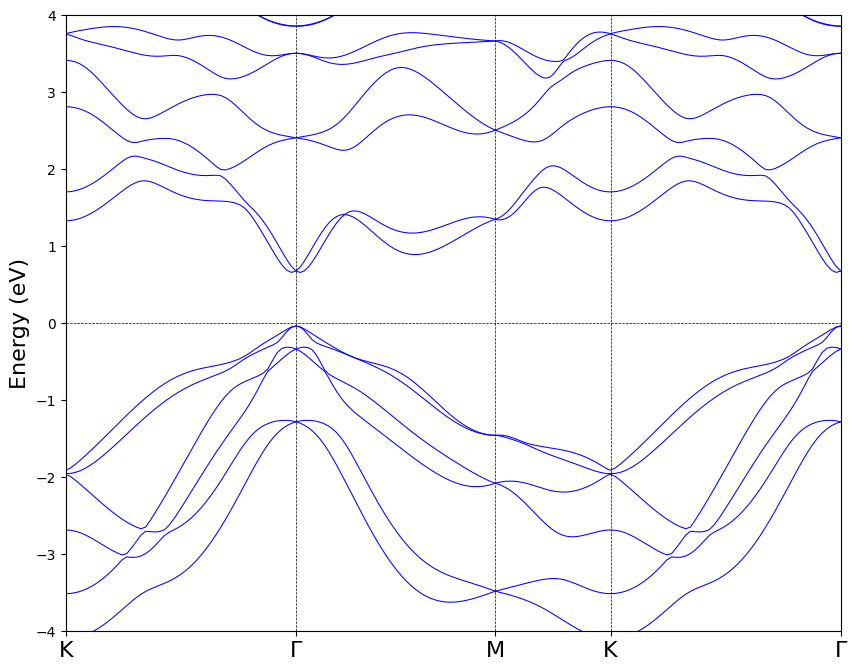

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0,1.040,1.941,2.461,3.501]  
high_symmetry_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=0.75)

plt.plot(k, bands[:, 18], color='red', lw=0.75)

plt.axhline(0, color='black', linestyle='--', lw=0.5)
#number of bands below fermi level in DFT data

num_bands_below_fermi = np.sum(bands[0, :] < 0) 

print(f"Number of bands below Fermi level in DFT data: {num_bands_below_fermi}")
for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)


plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)

plt.ylabel('Energy (eV)', fontsize=16)
plt.ylim(-4, 4)
plt.xlim(min(k), max(k))
plt.show()


In [8]:
import numpy as np

def read_poscar(filename="relaxed-POSCAR"):
    with open(filename, "r") as f:
        lines = f.readlines()

    scale = float(lines[1].strip())
    a_vec = [float(x) for x in lines[2].split()]
    b_vec = [float(x) for x in lines[3].split()]
    c_vec = [float(x) for x in lines[4].split()]
    species_line = lines[5].strip()
    counts_line  = lines[6].strip()
    coord_type   = lines[7].strip()
    atom_coords  = [lines[i].strip() for i in range(8, len(lines)) if lines[i].strip()]

    return scale, a_vec, b_vec, c_vec, species_line, counts_line, coord_type, atom_coords

strain_list = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16, 18]

scale, a_vec, b_vec, c_vec, species_line, counts_line, coord_type, atom_coords = read_poscar()

for i in strain_list:
    factor = 1 + i / 100

    # Only scale the in-plane (x, y) components; leave z untouched
    def strain_vec(v):
        return [v[0] * factor, v[1] * factor, v[2]]

    a_s = strain_vec(a_vec)
    b_s = strain_vec(b_vec)
    c_s = strain_vec(c_vec)

    filename = f"POSCAR-{i}"
    content = (
        f"Buckled BiAs strained {i}%\n"
        f"   {scale:.14f}\n"
        f"\t{a_s[0]:.15f}\t{a_s[1]:.15f}\t{a_s[2]:.15f}\n"
        f"\t{b_s[0]:.15f}\t{b_s[1]:.15f}\t{b_s[2]:.15f}\n"
        f"\t{c_s[0]:.15f}\t{c_s[1]:.15f}\t{c_s[2]:.15f}\n"
        f"   {species_line}\n"
        f"    {counts_line}\n"
        f"{coord_type}\n"
    )
    for coord in atom_coords:
        content += f"\t{coord}\n"

    with open(filename, "w") as f:
        f.write(content)

    print(f"Written: {filename}")

Written: POSCAR-2
Written: POSCAR-4
Written: POSCAR-6
Written: POSCAR-8
Written: POSCAR-10
Written: POSCAR-11
Written: POSCAR-12
Written: POSCAR-13
Written: POSCAR-14
Written: POSCAR-16
Written: POSCAR-18


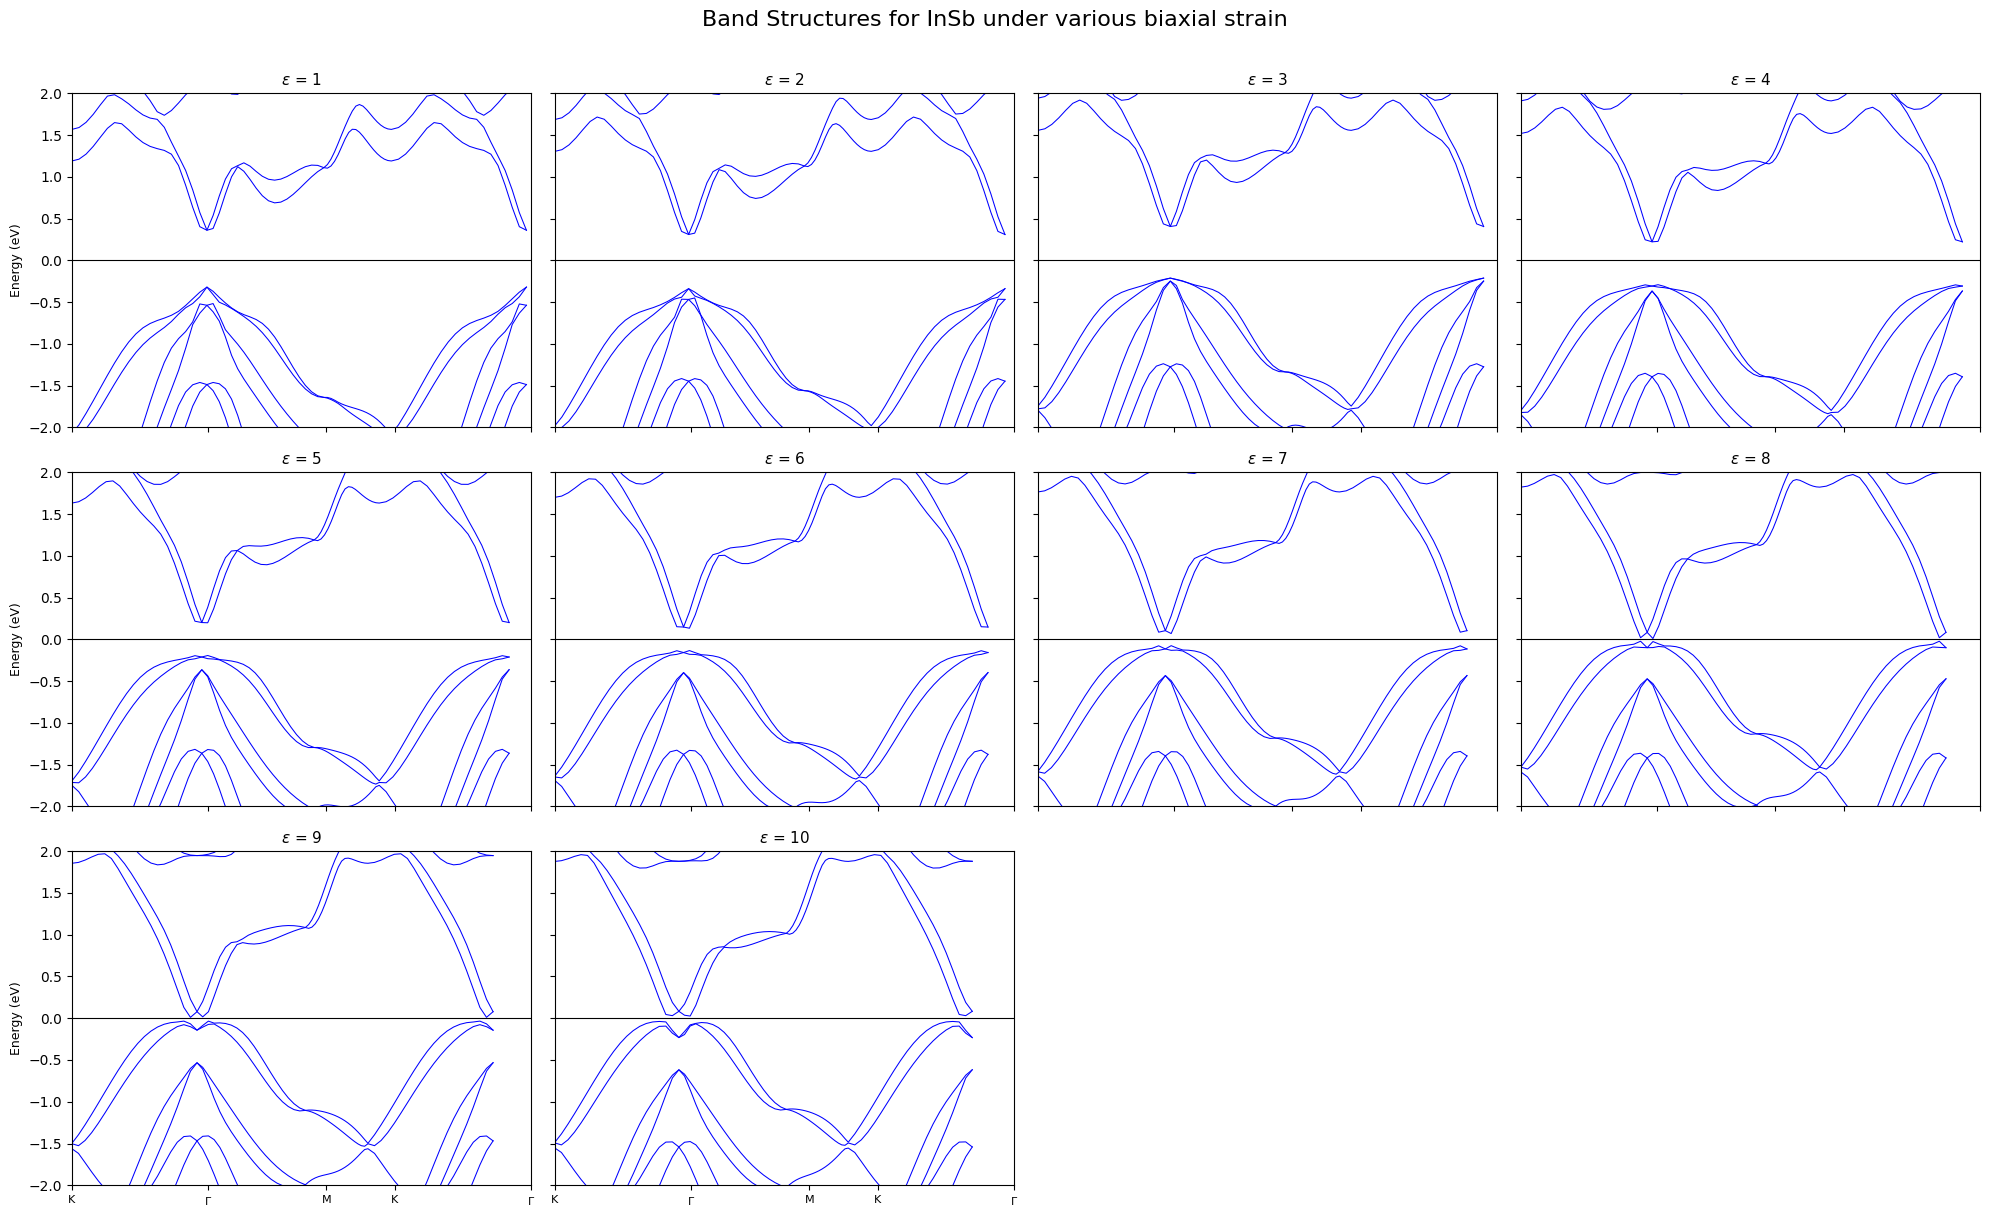

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Config ---
file_indices = [1,2,3,4,5,6,7,8,9,10]
high_symmetry_points = [0,1.040,1.941,2.461,3.501] 
high_sym_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

# --- Load all datasets ---
datasets = {i: np.loadtxt(f"{i}-REFORMATTED_BAND.dat") for i in file_indices}

# --- Layout: 4 cols, enough rows to fit all ---
n_plots = len(file_indices)
n_cols = 4
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, (idx, data) in zip(axes, datasets.items()):
    k = data[:, 0]
    bands = data[:, 1:]

    for i in range(bands.shape[1]):
        ax.plot(k, bands[:, i], color='blue', linewidth=0.75, label='DFT' if i == 0 else "")

    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlim(k.min(), k.max())
    ax.set_ylim(-2, 2)
    ax.set_xticks(high_symmetry_points)
    ax.set_xticklabels(high_sym_labels, fontsize=8)
    ax.set_title(rf'$\epsilon$ = {idx}', fontsize=11)

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('Energy (eV)', fontsize=9)

# Hide any unused subplots
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle('Band Structures for InSb under various biaxial strain', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2026-06-09 13:42:54,691                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(30, 101, 5)                                |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

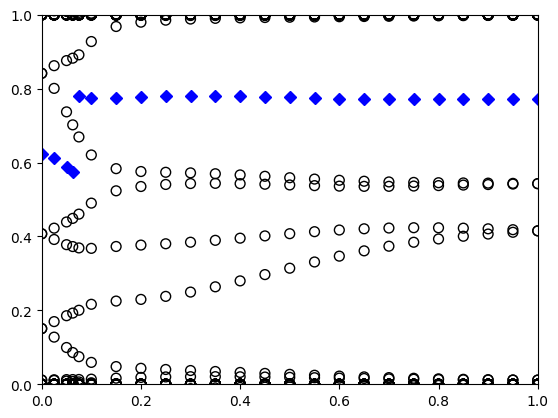

In [2]:
import z2pack
import tbmodels # type: ignore
import matplotlib.pyplot as plt

model = tbmodels.Model.from_wannier_files(hr_file='wannier90_hr.dat', wsvec_file='wannier90_wsvec.dat',occ=30)

system = z2pack.tb.System(model)
result = z2pack.surface.run(system=system, surface=lambda t1,t2: [t1/2, t2, 0.0],num_lines=21,iterator=range(30, 101, 5))

z2pack.plot.wcc(result)
print(z2pack.invariant.z2(result))
plt.show()

Number of bands below Fermi level in DFT data: 30


(-6.0, 6.0)

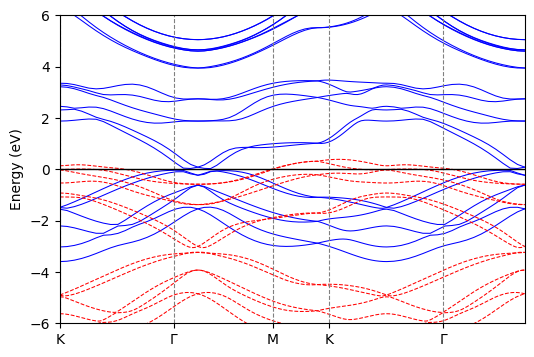

In [9]:
import numpy as np
import matplotlib.pyplot as plt

data_dft = np.loadtxt("10-REFORMATTED_BAND.dat")
data_wan = np.loadtxt("10-wannier90_band.dat")

k_dft = data_dft[:, 0]
band_dft = data_dft[:, 1:]

fermi = np.array([-1.3748,-1.6897,-1.9709,-2.1540,-2.2441,
                  -2.3166,-2.3540,-2.3914,-2.4484,-2.5217,
                  -2.6157,-2.7160,-2.8273,-2.9461,-3.0196])

k_wan = np.unique(data_wan[:, 0])
bands_wan = np.reshape(data_wan[:, 1], (-1, len(k_wan)))

high_symmetry_points = [0,0.780,1.456,1.846,2.626]
high_sym_labels = ['K',r'$\Gamma$','M', 'K', r'$\Gamma$',]

k_wan = k_wan * (max(k_dft) / max(k_wan))

#number of bands below fermi level in DFT data
num_bands_below_fermi = np.sum(band_dft[0, :] < 0) 
print(f"Number of bands below Fermi level in DFT data: {num_bands_below_fermi}")

plt.figure(figsize=(6,4))

for i in range(band_dft.shape[1]):
    plt.plot(k_dft, band_dft[:, i], color='blue', linewidth=0.75, label='DFT' if i == 0 else "")
  
for i in range(bands_wan.shape[0]):
    plt.plot(k_wan, bands_wan[i, :], color='red', linestyle='--', linewidth=0.75, label='Wannier90' if i == 0 else "")

for x in high_symmetry_points:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.8)

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.xticks(high_symmetry_points, high_sym_labels)
plt.ylabel('Energy (eV)')
#plt.title('Band Structure for $\epsilon$ = 24', fontsize=16)
plt.xlim(min(k_dft), max(k_dft))
plt.ylim(-6, 6)